In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('../data/Lens_GRN_June_2016_original FOR HACKATHON - Salil Lachke.xlsx')

In [11]:
df.head()

,S. No,Regulator,Target,New gene symbol for taget,Perturbation,Effect,Stage,Context,Context_2,Measurement,...,Phenotype 3,Function,Clinical Relevant Phenotype in Human,Reference,PMID,PMCID,TS of regulator,Unnamed: 24,TS of target,regulatorPlusLoc
0,417,Acvr1,Apoptosis,Apoptosis,-,o,E9.5,Acvrl-/-,AcvrlCKO/CKO; Le-Cre,TUNEL,...,NaN,NaN,NaN,"Rajagopal R, Huang J, Dattilo LK, Kaartinen V,...",19733164.0,PMC2783396,1548;TS16 surface ectoderm,NaN,1548;TS16 surface ectoderm,Acvr1 Lens ectoderm
1,414,Acvr1,Proliferation,Proliferation,-,-,E9.5,Acvrl-/-,AcvrlCKO/CKO; Le-Cre,BrdU,...,NaN,NaN,NaN,"Rajagopal R, Huang J, Dattilo LK, Kaartinen V,...",19733164.0,PMC2783396,1548;TS16 surface ectoderm,NaN,1548;TS16 surface ectoderm,Acvr1 Lens ectoderm
2,1728,Aldh1a1,Aldh1a1,Aldh1a1,-,-,P94,Aldh1a1-/-,Tg(Aldh1a1),Western Blotting,...,NaN,NaN,NaN,"Lassen, N., Bateman, J.B., Estey, T., Kuszak, ...",17567582.0,PMC2253645,Unknown,NaN,Unknown,Aldh1a1 Lens epithelium
3,1729,Aldh1a1,Aldh3a1,Aldh3a1,-,-,P94,Aldh1a1-/-,Tg(Aldh1a1),Western Blotting,...,NaN,NaN,NaN,"Lassen, N., Bateman, J.B., Estey, T., Kuszak, ...",17567582.0,PMC2253645,Unknown,NaN,Unknown,Aldh1a1 Lens epithelium
4,1727,"Aldh1a1, Aldh3a1","Aldh1a1, Aldh3a1","Aldh1a1, Aldh3a1",-,-,P274,Aldh1a1-/-/Aldh3al1-/-,"Tg(Aldh1a1,Aldh3al1)",Western Blotting,...,NaN,NaN,NaN,"Lassen, N., Bateman, J.B., Estey, T., Kuszak, ...",17567582.0,PMC2253645,Unknown,NaN,Unknown,"Aldh1a1, Aldh3a1 Lens epithelium"


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2726 entries, 0 to 2725
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   S. No                                  2726 non-null   int64  
 1   Regulator                              2726 non-null   object 
 2   Target                                 2726 non-null   object 
 3   New gene symbol for taget              2726 non-null   object 
 4   Perturbation                           2725 non-null   object 
 5   Effect                                 2726 non-null   object 
 6   Stage                                  2725 non-null   object 
 7   Context                                2726 non-null   object 
 8   Context_2                              2720 non-null   object 
 9   Measurement                            2719 non-null   object 
 10  Molecule Analyzed                      2719 non-null   object 
 11  Spec

In [10]:
df['regulatorPlusLoc'] = df['Regulator'] + ' ' +df['Tissue of regulator']

In [12]:
import networkx as nx

G = nx.from_pandas_edgelist(
    df,
    source="regulatorPlusLoc",
    target="New gene symbol for taget",
    edge_attr=True,
    create_using=nx.DiGraph()
)



Nodes = Total genes in your system

Edges = Total regulatory interactions

In [13]:
G.number_of_nodes()

874

In [14]:
G.number_of_edges()

1620

In [15]:
import numpy as np
np.mean([d for _, d in G.degree()])


3.7070938215102975

In-degree =
How many regulators control this gene?

High in-degree = Highly regulated gene

In [16]:
np.mean([d for _, d in G.in_degree()])


1.8535469107551488

Out-degree =
How many genes does this regulator control?

High out-degree = Master regulator

In [17]:
np.mean([d for _, d in G.out_degree()])

1.8535469107551488

Identify Master Regulators

In [18]:
sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:10]


[('Zeb2 Lens epithelium', 209),
 ('Foxe3 Lens epithelium', 109),
 ('Pax6 Lens epithelium', 76),
 ('Sparc Lens epithelium', 58),
 ('Crebbp, Ep300 Lens ectoderm', 44),
 ('Dicer1 Lens epithelium', 42),
 ('Pax6 Lens ectoderm', 39),
 ('Mafg, Mafk Lens', 38),
 ('Notch2 Lens epithelium', 31),
 ('Ilk Lens epithelium', 30)]

Identify Highly Regulated Genes

In [19]:
sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:10]


[('Pax6', 56),
 ('Proliferation', 51),
 ('Apoptosis', 41),
 ('Cdh1', 39),
 ('Foxe3', 37),
 ('Prox1', 36),
 ('Cryaa', 28),
 ('Sox2', 23),
 ('Cryb', 19),
 ('Ccnd1', 18)]

In [20]:
nx.degree_centrality(G)


{'Acvr1 Lens ectoderm': 0.002290950744558992,
 'Apoptosis': 0.046964490263459335,
 'Proliferation': 0.058419243986254296,
 'Aldh1a1 Lens epithelium': 0.002290950744558992,
 'Aldh1a1': 0.002290950744558992,
 'Aldh3a1': 0.003436426116838488,
 'Aldh1a1, Aldh3a1 Lens epithelium': 0.001145475372279496,
 'Aldh1a1, Aldh3a1': 0.001145475372279496,
 'Aldh3a1 Lens epithelium': 0.002290950744558992,
 'Ank2 Lens': 0.009163802978235968,
 'Dag1-alpha': 0.002290950744558992,
 'Sptbn2': 0.003436426116838488,
 'Cacna1c': 0.001145475372279496,
 'Dag1-beta': 0.002290950744558992,
 'Mlc2': 0.002290950744558992,
 'Nrcam': 0.001145475372279496,
 'p-Mlc': 0.002290950744558992,
 'Prx': 0.001145475372279496,
 'Apc Lens epithelium': 0.013745704467353952,
 'Acta2': 0.009163802978235968,
 'Ccnd1': 0.020618556701030927,
 'Cdh1': 0.044673539518900345,
 'Col4a4': 0.00572737686139748,
 'Coro1a': 0.010309278350515464,
 'Cryb': 0.021764032073310426,
 'H3f3a': 0.003436426116838488,
 'laminin': 0.003436426116838488,
 'Ma

Feed Forward Loops

In [21]:
nx.triads.triadic_census(G)


{'003': 109527764,
 '012': 1311080,
 '102': 0,
 '021D': 42106,
 '021U': 8674,
 '021C': 0,
 '111D': 0,
 '111U': 0,
 '030T': 0,
 '030C': 0,
 '201': 0,
 '120D': 0,
 '120U': 0,
 '120C': 0,
 '210': 0,
 '300': 0}

Feedback loops

In [22]:
list(nx.strongly_connected_components(G))


[{'Apoptosis'},
 {'Proliferation'},
 {'Acvr1 Lens ectoderm'},
 {'Aldh1a1'},
 {'Aldh3a1'},
 {'Aldh1a1 Lens epithelium'},
 {'Aldh1a1, Aldh3a1'},
 {'Aldh1a1, Aldh3a1 Lens epithelium'},
 {'Aldh3a1 Lens epithelium'},
 {'Dag1-alpha'},
 {'Sptbn2'},
 {'Cacna1c'},
 {'Dag1-beta'},
 {'Mlc2'},
 {'Nrcam'},
 {'p-Mlc'},
 {'Prx'},
 {'Ank2 Lens'},
 {'Acta2'},
 {'Ccnd1'},
 {'Cdh1'},
 {'Col4a4'},
 {'Coro1a'},
 {'Cryb'},
 {'H3f3a'},
 {'laminin'},
 {'Maf'},
 {'Pax6'},
 {'Apc Lens epithelium'},
 {'Apeh'},
 {'Cryaa'},
 {'Cryab'},
 {'Crygd'},
 {'Apeh Lens'},
 {'Crybb'},
 {'Cryga'},
 {'Sqstm1'},
 {'Atg5 Lens epithelium'},
 {'Bmp7'},
 {'Lens'},
 {'Lens placode'},
 {'Six3'},
 {'Sox2'},
 {'Bmp4 Optic vesicle'},
 {'Sfrp2'},
 {'Bmp7 Lens ectoderm'},
 {'Bmpr1a Lens ectoderm'},
 {'Acta1'},
 {'Foxe3'},
 {'Smad1'},
 {'Smad5'},
 {'Smad9'},
 {'Tjp1'},
 {'Bmpr1a, Acvr1 Lens ectoderm'},
 {'Cryba1'},
 {'Crygc'},
 {'Cdkn1b, Cdkn1c Transition zone'},
 {'Cdkn1c Transition zone'},
 {'Adamts14'},
 {'Adamts18'},
 {'Cdh2'},
 {'Cit

Successors = Genes regulated by FOXE3
Predecessors = Genes that regulate CRYAA

visualization example

One regulator and its downstream network.

Instead of messy whole network,
we inspect local regulatory architecture.

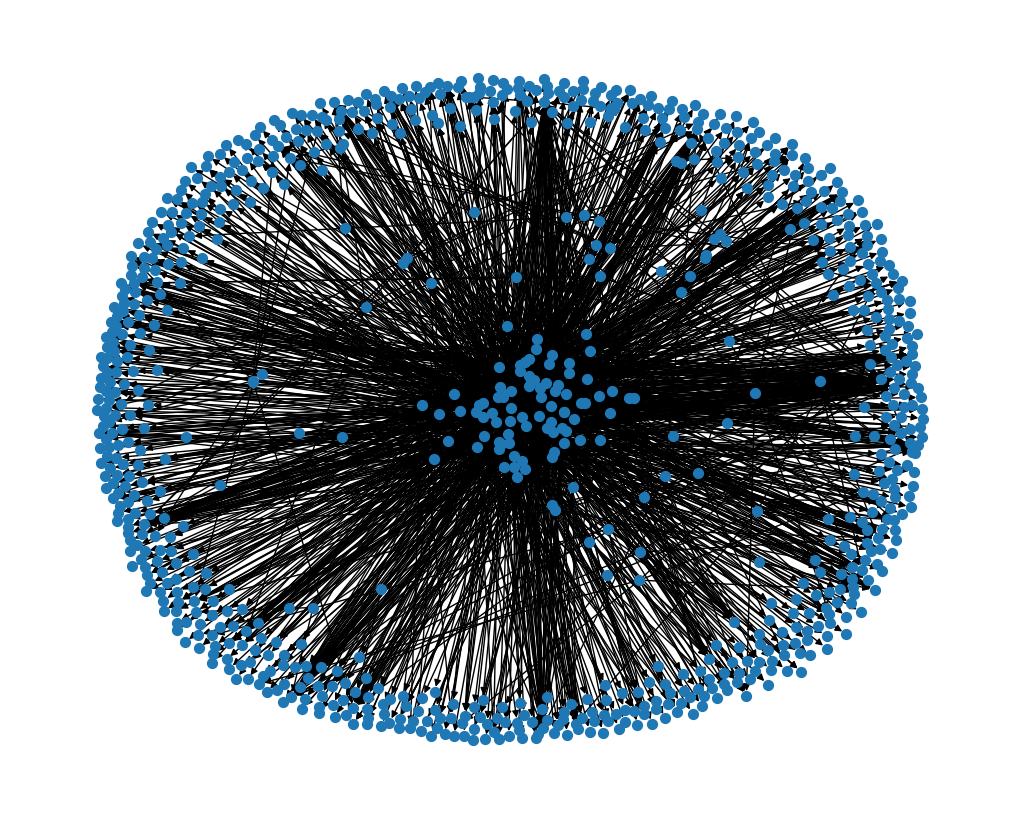

In [23]:
pos = nx.spring_layout(G, k=0.15)
plt.figure(figsize=(10,8))
nx.draw(G, pos, node_size=50, arrows=True)
plt.show()


In [25]:
sub_nodes = list(G.successors("Acvr1 Lens ectoderm"))
subG = G.subgraph(sub_nodes)
nx.draw(subG, with_labels=True)


In [26]:
keyword = "Acvr1 Lens ectoderm"

mask = df.apply(lambda col: col.astype(str).str.contains(keyword, case=False, na=False))
result = df[mask.any(axis=1)]

print(result)


     S. No      Regulator         Target New gene symbol for taget  \
0      417          Acvr1      Apoptosis                 Apoptosis   
1      414          Acvr1  Proliferation             Proliferation   
90     439  Bmpr1a, Acvr1          Acta1                     Acta1   
91     440  Bmpr1a, Acvr1          Acta1                     Acta1   
92     416  Bmpr1a, Acvr1      Apoptosis                 Apoptosis   
93     435  Bmpr1a, Acvr1          Cryaa                     Cryaa   
94     432  Bmpr1a, Acvr1          Foxe3                     Foxe3   
95     438  Bmpr1a, Acvr1   Lens placode              Lens placode   
96     426  Bmpr1a, Acvr1           Pax6                      Pax6   
97     413  Bmpr1a, Acvr1  Proliferation             Proliferation   
98     410  Bmpr1a, Acvr1          Smad1                     Smad1   
99     411  Bmpr1a, Acvr1          Smad5                     Smad5   
100    412  Bmpr1a, Acvr1          Smad9                     Smad9   
101    429  Bmpr1a, 